In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
print('All Libraries are imported successfully')

All Libraries are imported successfully


In [2]:
#loading the dataset
data = pd.read_csv('DOGE-USD.csv')
data.head(5)

,Date,Open,High,Low,Close,Adj Close,Volume
0,2017-11-09,0.001207,0.001415,0.001181,0.001415,0.001415,6259550.0
1,2017-11-10,0.001421,0.001431,0.001125,0.001163,0.001163,4246520.0
2,2017-11-11,0.001146,0.001257,0.001141,0.001201,0.001201,2231080.0
3,2017-11-12,0.001189,0.001210,0.001002,0.001038,0.001038,3288960.0
4,2017-11-13,0.001046,0.001212,0.001019,0.001211,0.001211,2481270.0


In [3]:
#statistical summary of the dataset
data.describe()

,Open,High,Low,Close,Adj Close,Volume
count,1760.000000,1760.000000,1760.000000,1760.000000,1760.000000,1.760000e+03
mean,0.059575,0.063096,0.056126,0.059619,0.059619,1.016258e+09
std,0.101325,0.109152,0.093695,0.101379,0.101379,3.563999e+09
min,0.001046,0.001210,0.001002,0.001038,0.001038,1.431720e+06
25%,0.002550,0.002616,0.002500,0.002548,0.002548,2.307671e+07
50%,0.003476,0.003603,0.003356,0.003495,0.003495,8.981855e+07
75%,0.070633,0.075035,0.068478,0.070657,0.070657,6.565853e+08
max,0.687801,0.737567,0.608168,0.684777,0.684777,6.941068e+10


In [5]:
#data correlation
correlation = data.corr(numeric_only=True)
print(correlation)

               Open      High       Low     Close  Adj Close    Volume
Open       1.000000  0.993904  0.993707  0.992514   0.992514  0.554850
High       0.993904  1.000000  0.986497  0.995104   0.995104  0.619321
Low        0.993707  0.986497  1.000000  0.994575   0.994575  0.519991
Close      0.992514  0.995104  0.994575  1.000000   1.000000  0.588678
Adj Close  0.992514  0.995104  0.994575  1.000000   1.000000  0.588678
Volume     0.554850  0.619321  0.519991  0.588678   0.588678  1.000000


In [9]:
# converting date safely (works even if this cell is re-run)
if 'Date' in data.columns:
    data['Date'] = pd.to_datetime(data['Date'], errors='coerce')
    data.set_index('Date', inplace=True)
else:
    data.index = pd.to_datetime(data.index, errors='coerce')

# printing the null values in the dataset
print(data.isnull().sum())

Open         1
High         1
Low          1
Close        1
Adj Close    1
Volume       1
dtype: int64


In [12]:
#checknig fr missing values
miss_val  = data.isnull().any()
print(miss_val)

Open         True
High         True
Low          True
Close        True
Adj Close    True
Volume       True
dtype: bool


In [14]:
#dropping the null values
data.dropna(inplace=True)
data.isnull().sum()

data.head()

,Open,High,Low,Close,Adj Close,Volume
Date,,,,,,
2017-11-09,0.001207,0.001415,0.001181,0.001415,0.001415,6259550.0
2017-11-10,0.001421,0.001431,0.001125,0.001163,0.001163,4246520.0
2017-11-11,0.001146,0.001257,0.001141,0.001201,0.001201,2231080.0
2017-11-12,0.001189,0.001210,0.001002,0.001038,0.001038,3288960.0
2017-11-13,0.001046,0.001212,0.001019,0.001211,0.001211,2481270.0


In [15]:
data.describe()

,Open,High,Low,Close,Adj Close,Volume
count,1760.000000,1760.000000,1760.000000,1760.000000,1760.000000,1.760000e+03
mean,0.059575,0.063096,0.056126,0.059619,0.059619,1.016258e+09
std,0.101325,0.109152,0.093695,0.101379,0.101379,3.563999e+09
min,0.001046,0.001210,0.001002,0.001038,0.001038,1.431720e+06
25%,0.002550,0.002616,0.002500,0.002548,0.002548,2.307671e+07
50%,0.003476,0.003603,0.003356,0.003495,0.003495,8.981855e+07
75%,0.070633,0.075035,0.068478,0.070657,0.070657,6.565853e+08
max,0.687801,0.737567,0.608168,0.684777,0.684777,6.941068e+10


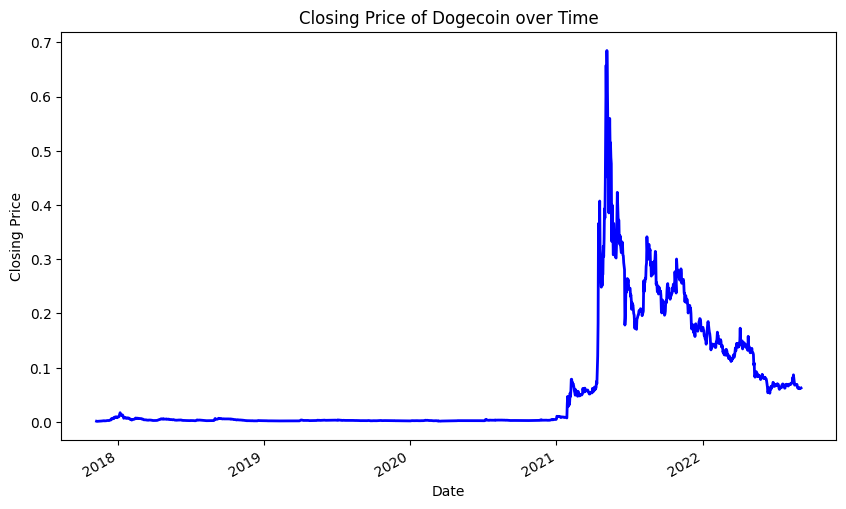

In [18]:
# first we will predict the closing price
plt.figure(figsize=(10, 6))
x = data.groupby('Date')['Close'].mean()
x.plot(linewidth=2, color='blue')
plt.xlabel('Date')
plt.ylabel('Closing Price')
plt.title('Closing Price of Dogecoin over Time')
plt.show()

In [20]:
data['gap'] = (data['High'] - data['Low']) * data['Volume']
data['y'] = data['High']/ data['Volume']
data['z'] = data['Low']/ data['Volume']
data['a'] = data['High'] / data['Low']
data['b'] = (data['High']/ data['Low']) * data['Volume']
abs(data.corr()['Close'].sort_values(ascending=False))

Close        1.000000
Adj Close    1.000000
High         0.995104
Low          0.994575
Open         0.992514
Volume       0.588678
b            0.456479
gap          0.383333
a            0.172057
z            0.063251
y            0.063868
Name: Close, dtype: float64

In [21]:
#high and low are most correlated so we will drop the other columns
data = data[["Close", "Volume", 'gap', 'a', 'b']]
data.head()

,Close,Volume,gap,a,b
Date,,,,,
2017-11-09,0.001415,6259550.0,1464.73470,1.198137,7.499800e+06
2017-11-10,0.001163,4246520.0,1299.43512,1.272000,5.401573e+06
2017-11-11,0.001201,2231080.0,258.80528,1.101665,2.457903e+06
2017-11-12,0.001038,3288960.0,684.10368,1.207585,3.971698e+06
2017-11-13,0.001211,2481270.0,478.88511,1.189401,2.951226e+06


In [23]:
df2 = data.tail(50)
train = df2[:40]
test = df2[-10:]
print(train.shape)
print(test.shape)

(40, 5)
(10, 5)


In [25]:
!pip install statsmodels

Defaulting to user installation because normal site-packages is not writeable
   ---------------------------------------- 0.0/9.6 MB ? eta -:--:--
   ---------------------------------------- 0.0/9.6 MB ? eta -:--:--
   - -------------------------------------- 0.3/9.6 MB ? eta -:--:--
   -- ------------------------------------- 0.5/9.6 MB 1.1 MB/s eta 0:00:09
   --- ------------------------------------ 0.8/9.6 MB 1.4 MB/s eta 0:00:07
   ----- ---------------------------------- 1.3/9.6 MB 1.6 MB/s eta 0:00:06
   ------- -------------------------------- 1.8/9.6 MB 1.7 MB/s eta 0:00:05
   -------- ------------------------------- 2.1/9.6 MB 1.7 MB/s eta 0:00:05
   --------- ------------------------------ 2.4/9.6 MB 1.6 MB/s eta 0:00:05
   ---------- ----------------------------- 2.6/9.6 MB 1.6 MB/s eta 0:00:05
   ------------ --------------------------- 2.9/9.6 MB 1.4 MB/s eta 0:00:05
   ------------- -------------------------- 3.1/9.6 MB 1.5 MB/s eta 0:00:05
   -------------- -------------

In [26]:
#applying sarimax model
from statsmodels.tsa.statespace.sarimax import SARIMAX
model = SARIMAX(endog=train['Close'],
                exog = train.drop('Close', axis=1),
                order=(2, 1, 1))


C:\Users\2004s\AppData\Roaming\Python\Python311\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
C:\Users\2004s\AppData\Roaming\Python\Python311\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)


In [27]:
#fitting the model
results = model.fit()
print(results.summary())

C:\Users\2004s\AppData\Roaming\Python\Python311\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


                               SARIMAX Results                                
Dep. Variable:                  Close   No. Observations:                   40
Model:               SARIMAX(2, 1, 1)   Log Likelihood                 189.901
Date:                Sat, 11 Apr 2026   AIC                           -363.802
Time:                        13:58:02   BIC                           -350.493
Sample:                    07-16-2022   HQIC                          -359.027
                         - 08-24-2022                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
Volume      5.157e-10   6.04e-11      8.539      0.000    3.97e-10    6.34e-10
gap         7.064e-09   6.94e-10     10.176      0.000     5.7e-09    8.42e-09
a              0.0301   2.45e-12   1.23e+10      0.0

In [29]:
#predicting the values on time series
start = 30
end = 49
pred = results.predict(start = start, end=end, exog=test.drop('Close', axis=1))
print(pred)

2022-08-15    0.078540
2022-08-16    0.088795
2022-08-17    0.080453
2022-08-18    0.074938
2022-08-19    0.071473
2022-08-20    0.068543
2022-08-21    0.069766
2022-08-22    0.069005
2022-08-23    0.068278
2022-08-24    0.068893
2022-08-25    0.068621
2022-08-26    0.067360
2022-08-27    0.067803
2022-08-28    0.067774
2022-08-29    0.067750
2022-08-30    0.067708
2022-08-31    0.067702
2022-09-01    0.067621
2022-09-02    0.067644
2022-09-03    0.067501
Freq: D, Name: predicted_mean, dtype: float64


<Axes: xlabel='Date'>

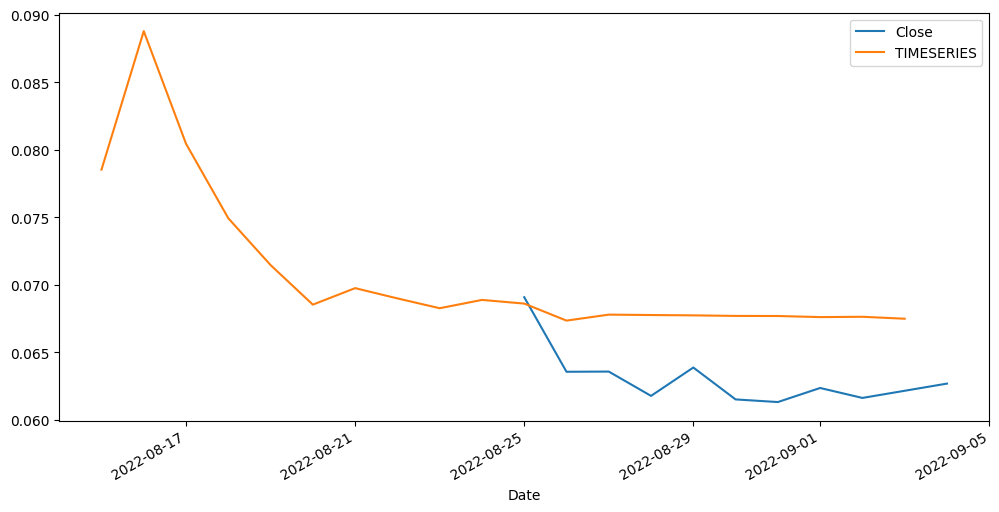

In [30]:
#plotting the pred
test['Close'].plot(legend= True, figsize=(12,6))
pred.plot(label='TIMESERIES', legend= True)

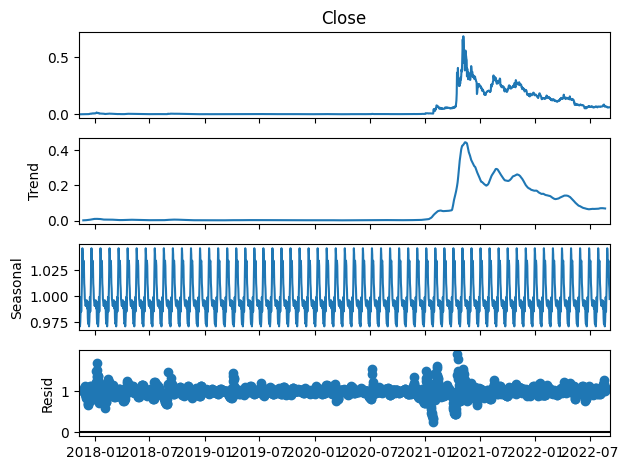

In [35]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.seasonal import seasonal_decompose

# read the dataset with datetime index
data1 = pd.read_csv('DOGE-USD.csv', index_col='Date', parse_dates=True)
data1 = data1.sort_index()

# ensure regular daily frequency for decomposition
data1 = data1.asfreq('D')
data1['Close'] = data1['Close'].interpolate()

# use explicit period to avoid frequency inference errors
result = seasonal_decompose(data1['Close'], model='multiplicative', period=30)

result.plot()
plt.show()